In [1]:
import os
import zipfile
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
import requests


In [ ]:
import zipfile
import os

zip_path = "../Dataset/kagglecatsanddogs_5340.zip"
extract_path = "../animal"

# check file exists
if not os.path.exists(zip_path):
    raise FileNotFoundError("ZIP file not found!")

# check if it's really a zip file
if not zipfile.is_zipfile(zip_path):
    raise ValueError("This file is NOT a valid ZIP file (download is corrupted or HTML file).")

print("Valid ZIP file ")

# unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside ZIP (first 10):")
    print(zip_ref.namelist()[:10])   # show preview
    
    zip_ref.extractall(extract_path)

print("Unzipping completed ")
print("Extracted to:", extract_path)

Valid ZIP file ✔️
Files inside ZIP (first 10):
['PetImages/Cat/', 'PetImages/Cat/0.jpg', 'PetImages/Cat/1.jpg', 'PetImages/Cat/10.jpg', 'PetImages/Cat/100.jpg', 'PetImages/Cat/1000.jpg', 'PetImages/Cat/10000.jpg', 'PetImages/Cat/10001.jpg', 'PetImages/Cat/10002.jpg', 'PetImages/Cat/10003.jpg']
Unzipping completed ✔️
Extracted to: ../animal


In [2]:
basedir='PetImages'
cat=basedir+'/Cat'
dog=basedir+'/Dog'

files_cat=os.listdir(cat)
files_dog=os.listdir(dog)

print('Number of cat images:', len(files_cat))
print('Number of dog images:', len(files_dog))

Number of cat images: 12497
Number of dog images: 12494


In [3]:
removed = 0
for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(basedir, folder)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = tf.io.read_file(img_path)
            img = tf.image.decode_image(img)
        except:
            print("Removing corrupted file:", img_path)
            os.remove(img_path)
            removed += 1

print("Total removed files:", removed)

Total removed files: 0


In [4]:
batch_size = 32
img_height = 180
img_width = 180

In [25]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  basedir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.


In [26]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  basedir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [27]:
class_names = train_ds.class_names
print(class_names)

['Cat', 'Dog']


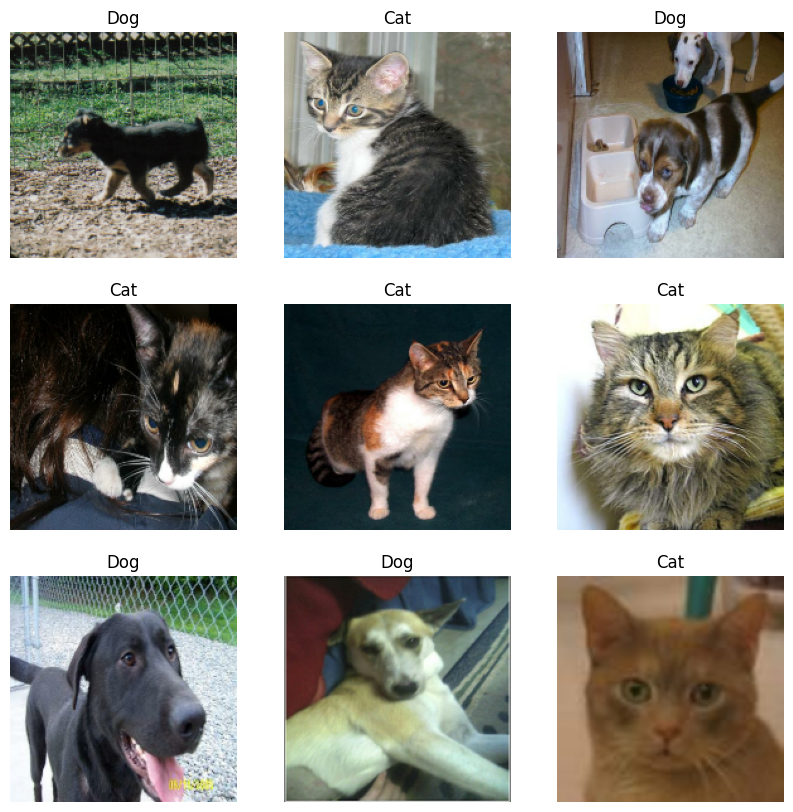

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(3):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [29]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [30]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation = keras.Sequential(
  [
    layers.Rescaling(1./255.0, input_shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

e:\MyPythonWorkspace\envs\deeplearningprj\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(1, activation='sigmoid', name="outputs")
])

In [43]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [44]:
epochs = 2
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 298s 447ms/step - accuracy: 0.6300 - loss: 0.6387 - val_accuracy: 0.7035 - val_loss: 0.5644
Epoch 2/2
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 423ms/step - accuracy: 0.7238 - loss: 0.5450 - val_accuracy: 0.7419 - val_loss: 0.5114


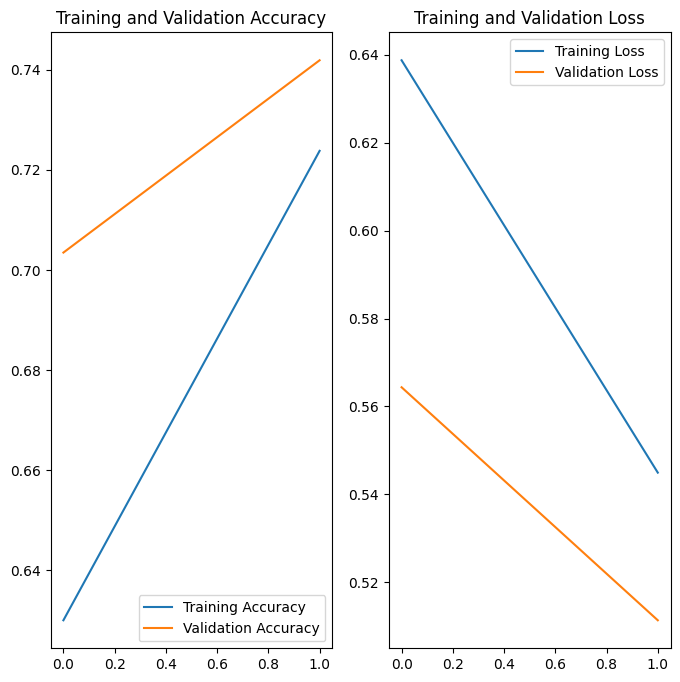

In [45]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()